# Exploratory Data Analysis — Emotion Classification

**Dataset:** `data1_train.csv`  
**Task:** Multi-label emotion classification (6 emotions + neutral)  
**Emotions:** `anger`, `disgust`, `fear`, `joy`, `sadness`, `surprise`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

EMOTION_COLS = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
EMOTION_COLORS = {
    'anger':    '#e74c3c',
    'disgust':  '#8e44ad',
    'fear':     '#2c3e50',
    'joy':      '#f1c40f',
    'sadness':  '#3498db',
    'surprise': '#1abc9c',
    'neutral':  '#95a5a6'
}

df = pd.read_csv('data1_train.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (50248, 8)


,text,label,anger,disgust,fear,joy,sadness,surprise
0,“Worry is a down payment on a problem you may ...,['joy'],0,0,0,1,0,0
1,Whatever you decide to do make sure it makes y...,['joy'],0,0,0,1,0,0
2,@Max_Kellerman it also helps that the majorit...,"['anger', 'joy', 'disgust']",1,1,0,1,0,0


---
## 1. Basic Info & Missing Values

In [2]:
# ── Data types & nulls ──────────────────────────────────────────────
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(2),
    'unique': df.nunique()
})
print('=== Dataset Info ===')
print(f'Total samples : {len(df):,}')
print(f'Total columns : {df.shape[1]}')
print()
display(info_df)

=== Dataset Info ===
Total samples : 50,248
Total columns : 8



,dtype,null_count,null_%,unique
text,object,0,0.0,50065
label,object,0,0.0,61
anger,int64,0,0.0,2
disgust,int64,0,0.0,2
fear,int64,0,0.0,2
joy,int64,0,0.0,2
sadness,int64,0,0.0,2
surprise,int64,0,0.0,2


---
## 2. Label / Class Distribution

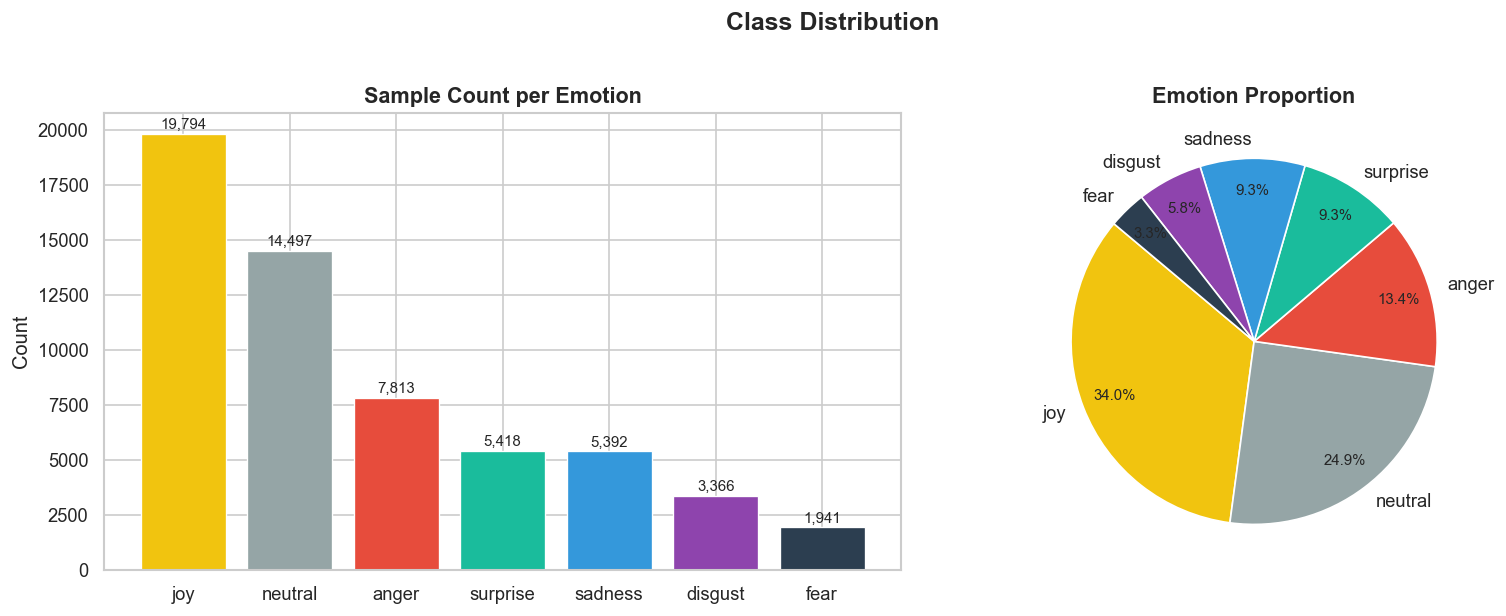


=== Class Distribution Table ===


,emotion,count,percentage
0,joy,19794,39.39%
1,neutral,14497,28.85%
2,anger,7813,15.55%
3,surprise,5418,10.78%
4,sadness,5392,10.73%
5,disgust,3366,6.70%
6,fear,1941,3.86%


In [ ]:
# Emotion column binary counts 
emotion_counts = df[EMOTION_COLS].sum().sort_values(ascending=False)

# Add neutral
neutral_count = (df[EMOTION_COLS].sum(axis=1) == 0).sum()
all_counts = emotion_counts.copy()
all_counts['neutral'] = neutral_count
all_counts = all_counts.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = [EMOTION_COLORS[e] for e in all_counts.index]
bars = axes[0].bar(all_counts.index, all_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Sample Count per Emotion', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, all_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    all_counts.values, labels=all_counts.index,
    autopct='%1.1f%%', colors=colors,
    startangle=140, pctdistance=0.82
)
for t in autotexts: t.set_fontsize(9)
axes[1].set_title('Emotion Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Table
count_df = pd.DataFrame({
    'emotion': all_counts.index,
    'count': all_counts.values,
    'percentage': (all_counts.values / len(df) * 100).round(2)
})
print('\n=== Class Distribution Table ===')
display(count_df.style.bar(subset=['count'], color='#5fba7d').format({'percentage': '{:.2f}%'}))

---
## 3. Multi-label Analysis — Number of Emotions per Sample

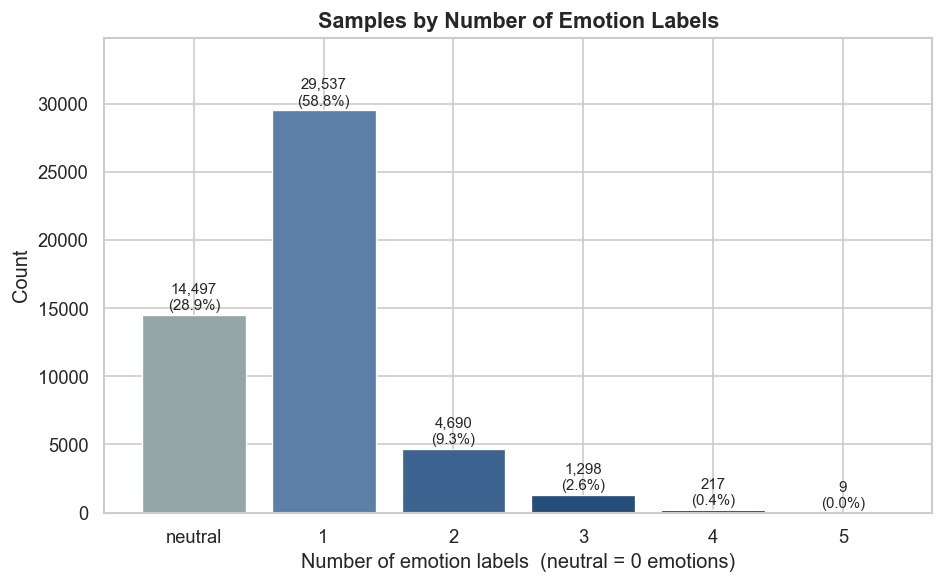


=== Multi-label Distribution ===


,label_group,count,percentage
0,neutral,14497,28.85%
1,1,29537,58.78%
2,2,4690,9.33%
3,3,1298,2.58%
4,4,217,0.43%
5,5,9,0.02%


In [ ]:
df['num_emotions'] = df[EMOTION_COLS].sum(axis=1)

def label_group(n):
    if n == 0:
        return 'neutral'
    return str(n)

df['emotion_group'] = df['num_emotions'].apply(label_group)

order = ['neutral', '1', '2', '3', '4', '5']
group_counts = df['emotion_group'].value_counts().reindex(order)
group_pct    = group_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#95a5a6', '#5b7fa6', '#3d6491', '#254e78', '#0f3460', '#070f2b']
bars = ax.bar(group_counts.index, group_counts.values,
              color=colors, edgecolor='white', linewidth=0.8)

for bar, val, pct in zip(bars, group_counts.values, group_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_title('Samples by Number of Emotion Labels', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of emotion labels  (neutral = 0 emotions)')
ax.set_ylabel('Count')
ax.set_ylim(0, group_counts.max() * 1.18)
plt.tight_layout()
plt.show()

# Table
multi_df = pd.DataFrame({
    'label_group':  group_counts.index,
    'count':        group_counts.values,
    'percentage':   group_pct.round(2).values
})
print('\n=== Multi-label Distribution ===')
display(multi_df.style.format({'percentage': '{:.2f}%'})
                      .bar(subset=['count'], color='#5b7fa6'))

---
## 4. Emotion Co-occurrence & Correlation

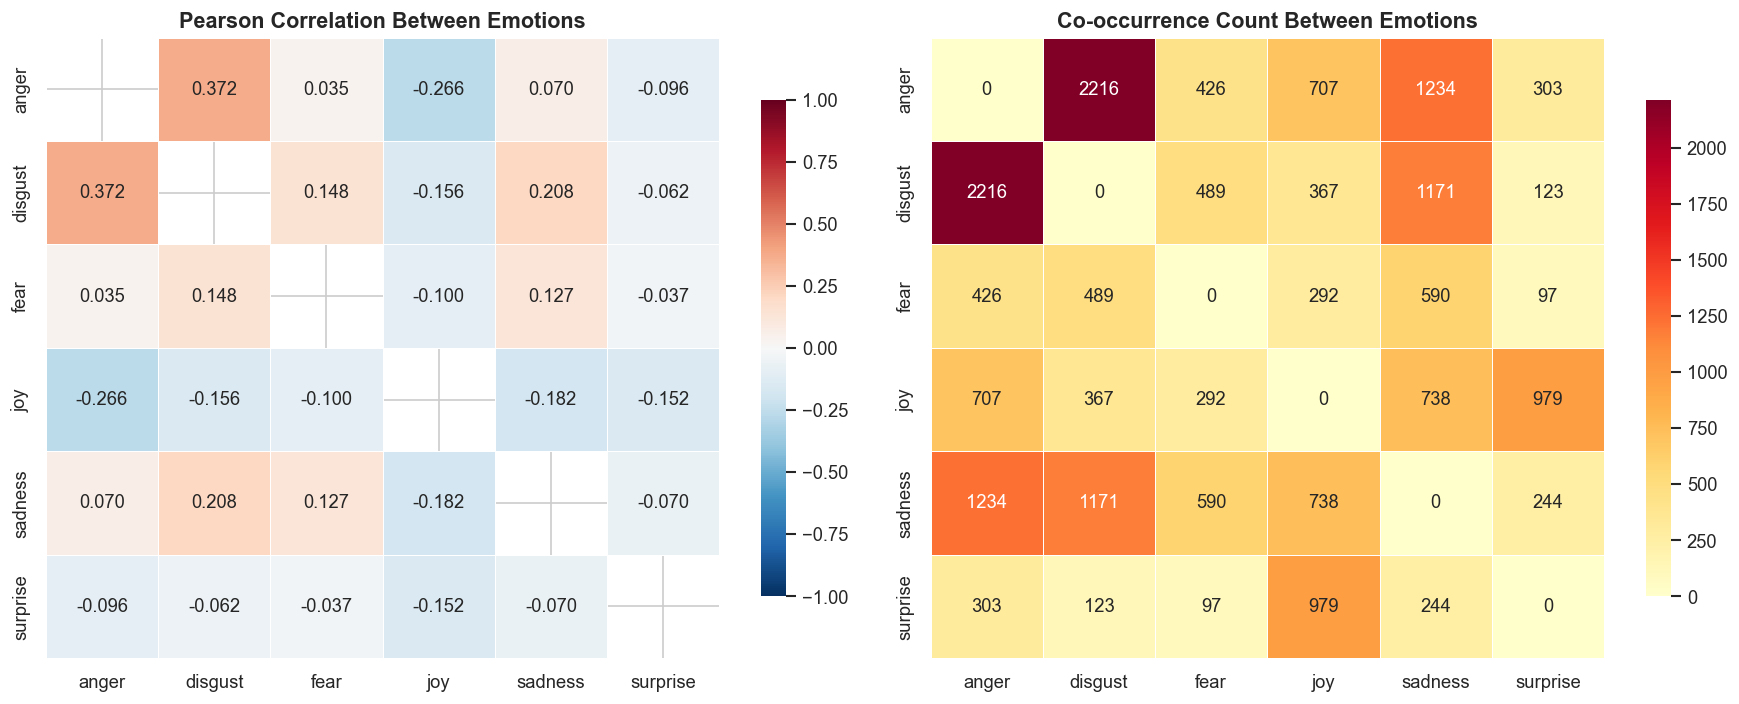


=== Top Emotion Pairs by Correlation ===


,emotion_1,emotion_2,correlation,co_occurrence
0,anger,disgust,0.371800,2216
7,disgust,sadness,0.208300,1171
5,disgust,fear,0.148300,489
10,fear,sadness,0.127400,590
3,anger,sadness,0.070200,1234
1,anger,fear,0.035400,426
11,fear,surprise,-0.037400,97
8,disgust,surprise,-0.061600,123
14,sadness,surprise,-0.069900,244
4,anger,surprise,-0.095500,303


In [6]:
emotion_matrix = df[EMOTION_COLS]
corr = emotion_matrix.corr()
co_matrix = emotion_matrix.T.dot(emotion_matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Correlation heatmap
mask = np.eye(len(EMOTION_COLS), dtype=bool)
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Between Emotions', fontsize=13, fontweight='bold')

# Co-occurrence heatmap
co_no_diag = co_matrix.copy()
np.fill_diagonal(co_no_diag.values, 0)
sns.heatmap(co_no_diag, annot=True, fmt='d',
            cmap='YlOrRd', ax=axes[1], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Co-occurrence Count Between Emotions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Top pairs table
pairs = []
for i in range(len(EMOTION_COLS)):
    for j in range(i+1, len(EMOTION_COLS)):
        e1, e2 = EMOTION_COLS[i], EMOTION_COLS[j]
        pairs.append({'emotion_1': e1, 'emotion_2': e2,
                      'correlation': round(corr.loc[e1, e2], 4),
                      'co_occurrence': int(co_matrix.loc[e1, e2])})
pairs_df = pd.DataFrame(pairs).sort_values('correlation', ascending=False)
print('\n=== Top Emotion Pairs by Correlation ===')
display(pairs_df.style.background_gradient(subset=['correlation'], cmap='RdBu_r', vmin=-1, vmax=1)
                      .background_gradient(subset=['co_occurrence'], cmap='YlOrRd'))

---
## 5. Sentence Length Analysis

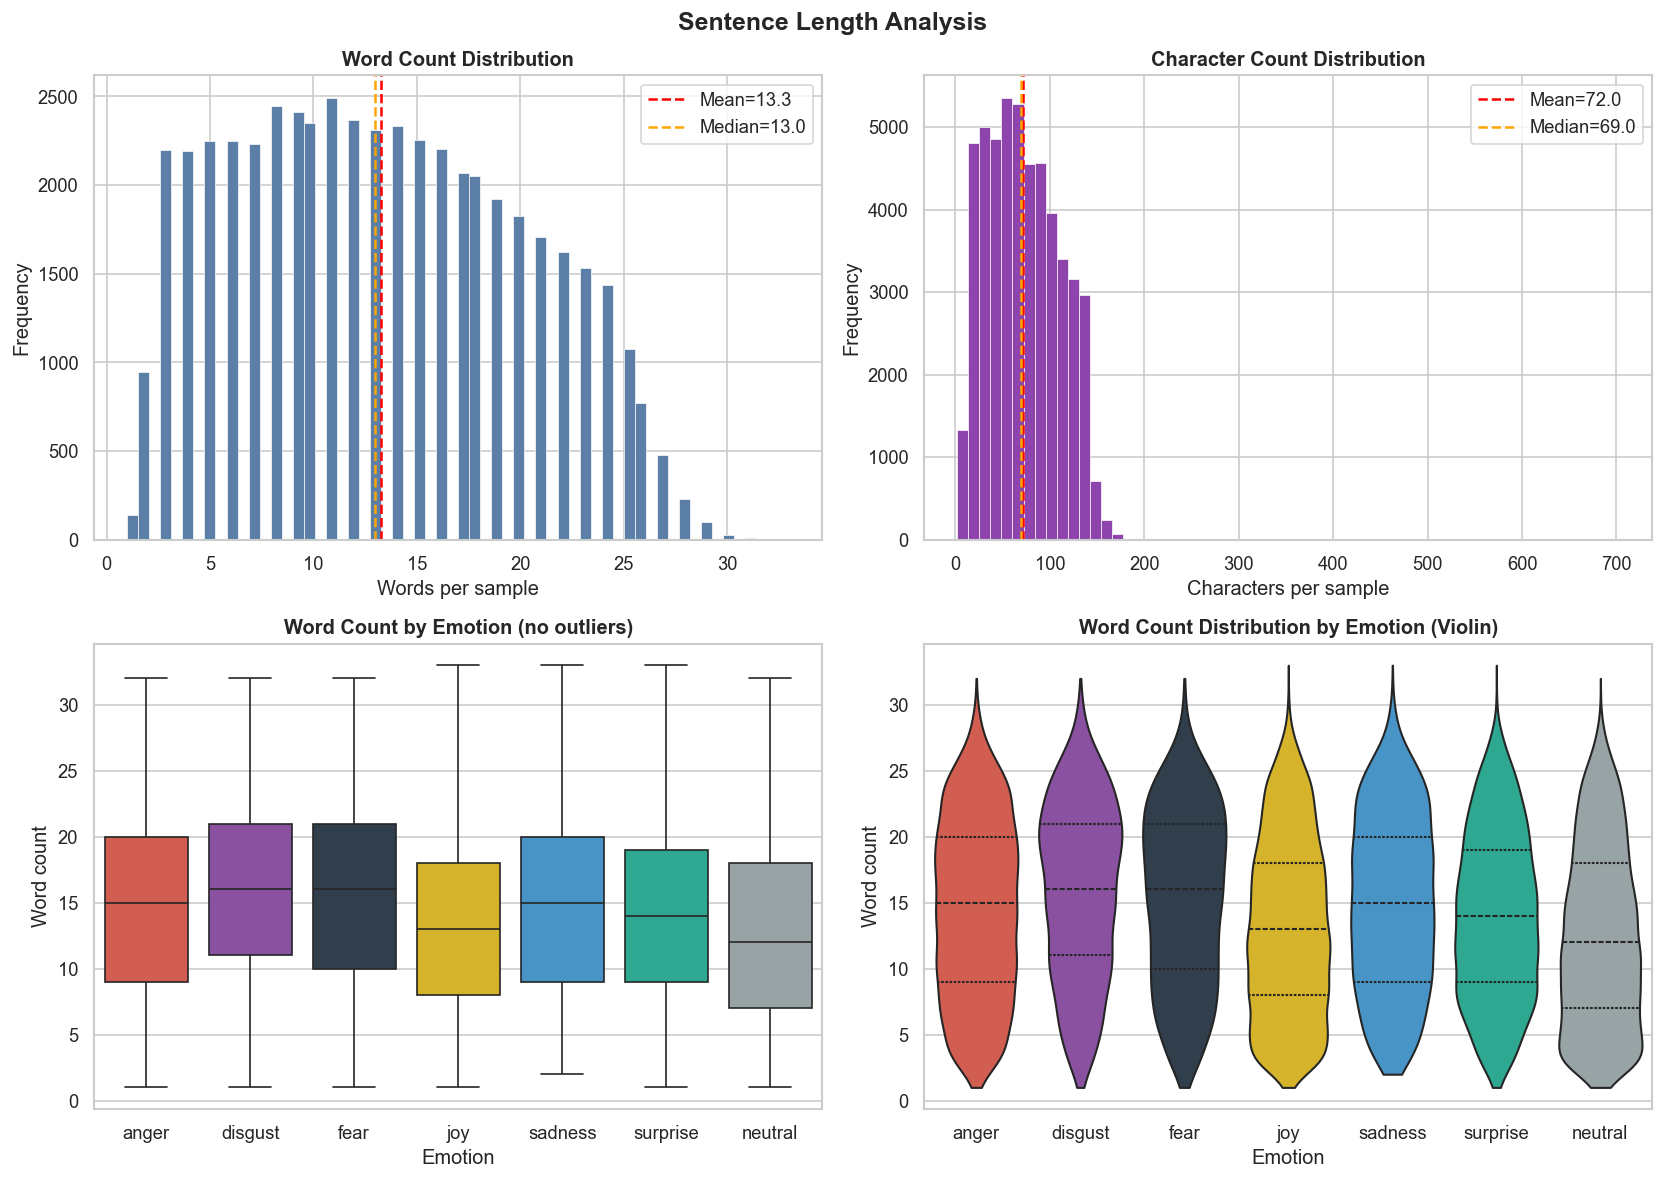


=== Length Statistics by Emotion ===


,mean,median,std,min,max
emotion,,,,,
anger,14.540000,15.000000,6.800000,1,32
disgust,15.860000,16.000000,6.690000,1,32
fear,15.240000,16.000000,6.700000,1,32
joy,13.210000,13.000000,6.740000,1,33
neutral,12.520000,12.000000,6.820000,1,32
sadness,14.960000,15.000000,6.690000,2,33
surprise,14.000000,14.000000,6.380000,1,33


In [7]:
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().apply(len)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Word length distribution
axes[0,0].hist(df['word_len'], bins=60, color='#5b7fa6', edgecolor='white', linewidth=0.4)
axes[0,0].axvline(df['word_len'].mean(), color='red', linestyle='--', label=f"Mean={df['word_len'].mean():.1f}")
axes[0,0].axvline(df['word_len'].median(), color='orange', linestyle='--', label=f"Median={df['word_len'].median():.1f}")
axes[0,0].set_title('Word Count Distribution', fontweight='bold')
axes[0,0].set_xlabel('Words per sample'); axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Char length distribution
axes[0,1].hist(df['char_len'], bins=60, color='#8e44ad', edgecolor='white', linewidth=0.4)
axes[0,1].axvline(df['char_len'].mean(), color='red', linestyle='--', label=f"Mean={df['char_len'].mean():.1f}")
axes[0,1].axvline(df['char_len'].median(), color='orange', linestyle='--', label=f"Median={df['char_len'].median():.1f}")
axes[0,1].set_title('Character Count Distribution', fontweight='bold')
axes[0,1].set_xlabel('Characters per sample'); axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Box plot: word length by emotion
melt_list = []
for emo in EMOTION_COLS:
    sub = df[df[emo] == 1][['word_len']].copy()
    sub['emotion'] = emo
    melt_list.append(sub)
neutral_sub = df[df['num_emotions'] == 0][['word_len']].copy()
neutral_sub['emotion'] = 'neutral'
melt_list.append(neutral_sub)
emo_len_df = pd.concat(melt_list)

sns.boxplot(data=emo_len_df, x='emotion', y='word_len',
            palette=EMOTION_COLORS, ax=axes[1,0],
            showfliers=False)
axes[1,0].set_title('Word Count by Emotion (no outliers)', fontweight='bold')
axes[1,0].set_xlabel('Emotion'); axes[1,0].set_ylabel('Word count')

# Violin plot
sns.violinplot(data=emo_len_df, x='emotion', y='word_len',
               palette=EMOTION_COLORS, ax=axes[1,1],
               inner='quartile', cut=0)
axes[1,1].set_title('Word Count Distribution by Emotion (Violin)', fontweight='bold')
axes[1,1].set_xlabel('Emotion'); axes[1,1].set_ylabel('Word count')

plt.suptitle('Sentence Length Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats table
print('\n=== Length Statistics by Emotion ===')
len_stats = emo_len_df.groupby('emotion')['word_len'].agg(['mean','median','std','min','max']).round(2)
display(len_stats.style.background_gradient(subset=['mean'], cmap='Blues'))

---
## 6. Special Token Analysis (URLs, Mentions, Hashtags, Emojis)

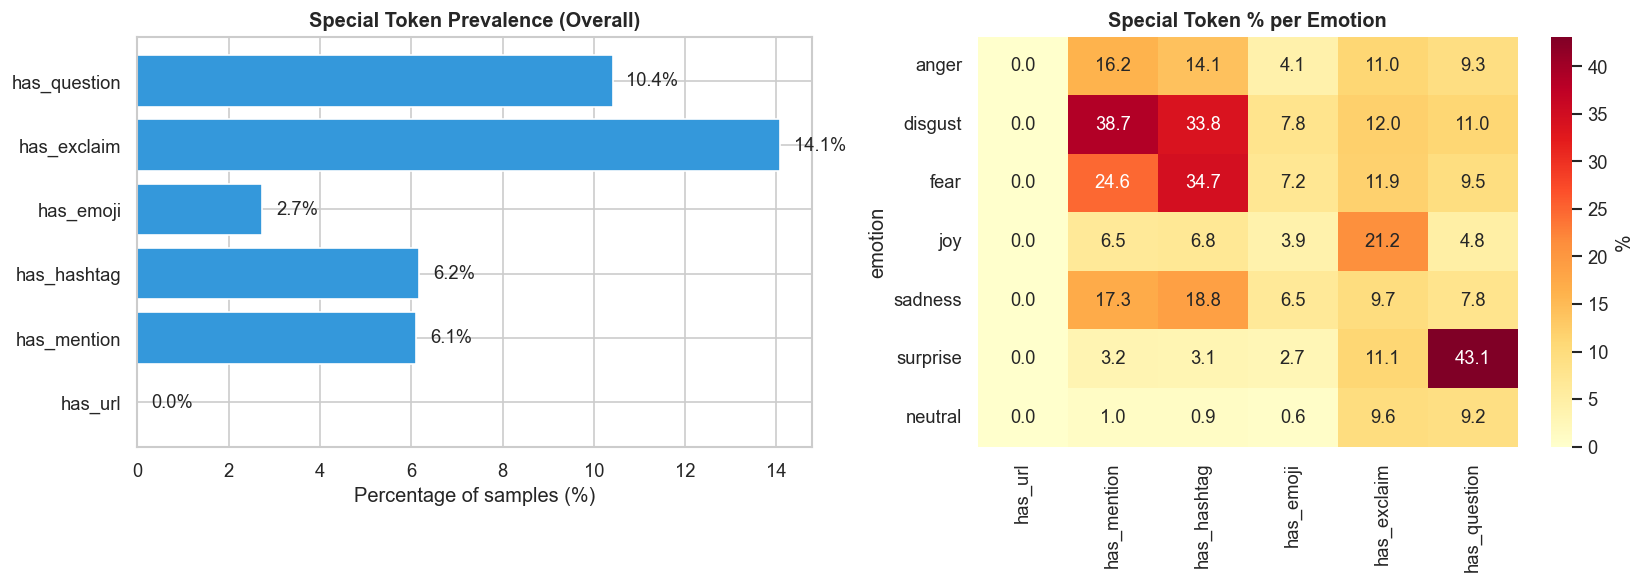


=== Special Token Rate per Emotion (%) ===


,has_url,has_mention,has_hashtag,has_emoji,has_exclaim,has_question
emotion,,,,,,
anger,0.000000,16.170000,14.100000,4.110000,10.970000,9.280000
disgust,0.000000,38.740000,33.780000,7.780000,12.030000,11.020000
fear,0.000000,24.630000,34.670000,7.210000,11.900000,9.480000
joy,0.000000,6.550000,6.760000,3.920000,21.170000,4.780000
sadness,0.000000,17.340000,18.810000,6.450000,9.700000,7.840000
surprise,0.000000,3.210000,3.120000,2.730000,11.090000,43.130000
neutral,0.000000,0.980000,0.880000,0.620000,9.630000,9.150000


In [8]:
df['has_url']     = df['text'].str.contains(r'http\S+|www\.\S+', regex=True, na=False).astype(int)
df['has_mention'] = df['text'].str.contains(r'@\w+', regex=True, na=False).astype(int)
df['has_hashtag'] = df['text'].str.contains(r'#\w+', regex=True, na=False).astype(int)
df['has_emoji']   = df['text'].str.contains(
    r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]',
    regex=True, na=False).astype(int)
df['has_exclaim'] = df['text'].str.contains(r'!', na=False).astype(int)
df['has_question']= df['text'].str.contains(r'\?', na=False).astype(int)
df['is_upper_pct']= df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(x),1))

special_cols = ['has_url','has_mention','has_hashtag','has_emoji','has_exclaim','has_question']

# Overall rates
overall_rates = df[special_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(overall_rates.index, overall_rates.values, color='#3498db')
axes[0].set_xlabel('Percentage of samples (%)')
axes[0].set_title('Special Token Prevalence (Overall)', fontweight='bold')
for i, v in enumerate(overall_rates.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center')

# Per emotion
emo_special = []
for emo in EMOTION_COLS + ['neutral']:
    if emo == 'neutral':
        sub = df[df['num_emotions'] == 0]
    else:
        sub = df[df[emo] == 1]
    row = {'emotion': emo}
    for col in special_cols:
        row[col] = sub[col].mean() * 100
    emo_special.append(row)
emo_special_df = pd.DataFrame(emo_special).set_index('emotion')

sns.heatmap(emo_special_df, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('Special Token % per Emotion', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== Special Token Rate per Emotion (%) ===')
display(emo_special_df.round(2).style.background_gradient(cmap='YlOrRd'))

---
## 7. Punctuation & Capitalization Analysis

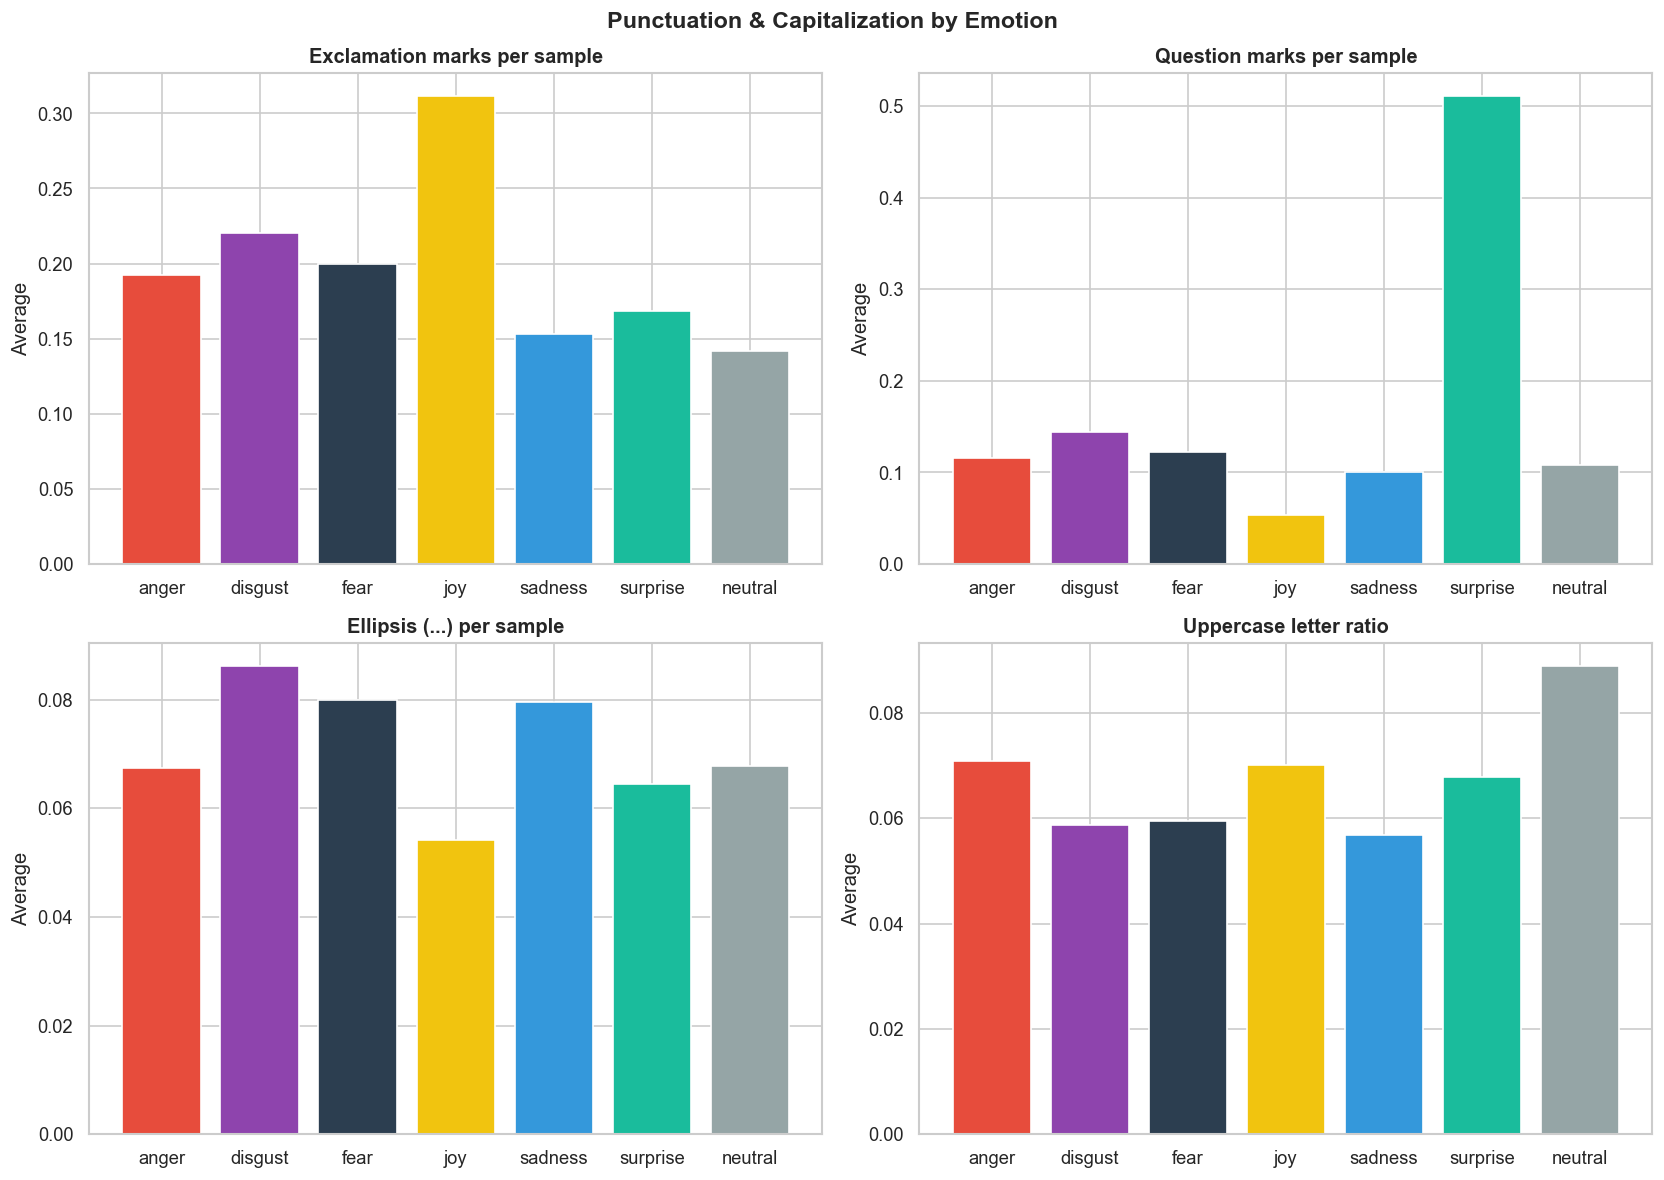

In [9]:
df['num_exclaim']  = df['text'].str.count('!')
df['num_question'] = df['text'].str.count('\\?')
df['num_ellipsis'] = df['text'].str.count('\\.\.\\.')
df['upper_pct']    = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len([c for c in str(x) if c.isalpha()]), 1)
)

punct_cols = ['num_exclaim', 'num_question', 'num_ellipsis', 'upper_pct']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = ['Exclamation marks per sample', 'Question marks per sample',
          'Ellipsis (...) per sample', 'Uppercase letter ratio']
colors = ['#e74c3c', '#3498db', '#8e44ad', '#f39c12']

for ax, col, title, color in zip(axes.flatten(), punct_cols, titles, colors):
    per_emo = []
    for emo in EMOTION_COLS:
        per_emo.append(df[df[emo] == 1][col].mean())
    per_emo_neutral = df[df['num_emotions'] == 0][col].mean()
    labels = EMOTION_COLS + ['neutral']
    vals   = per_emo + [per_emo_neutral]
    bar_colors = [EMOTION_COLORS[e] for e in labels]
    ax.bar(labels, vals, color=bar_colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Average')

plt.suptitle('Punctuation & Capitalization by Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Top N-gram Analysis per Emotion

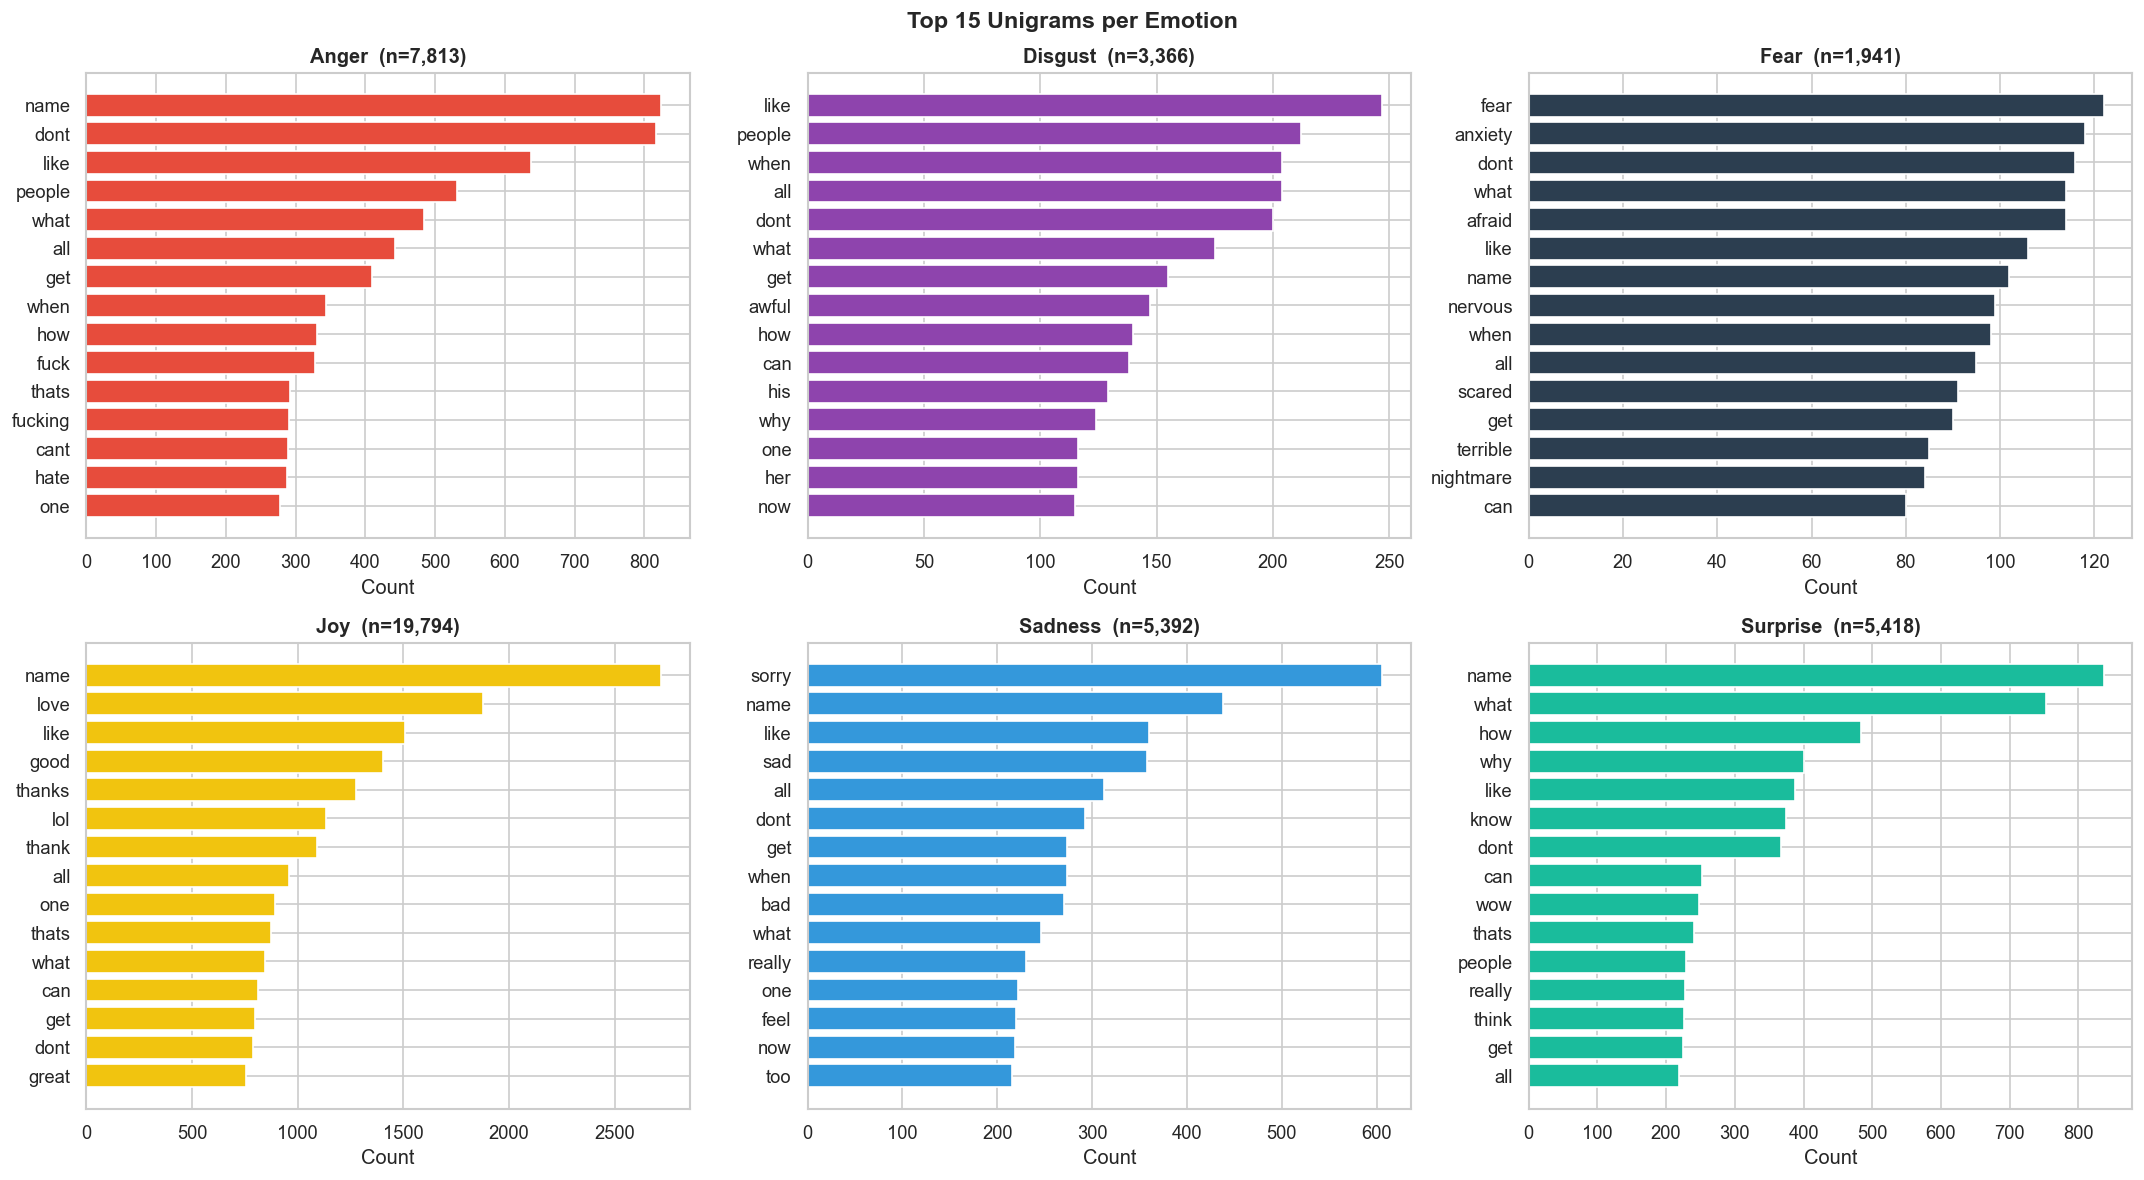

In [10]:
from collections import Counter

STOPWORDS = set([
    'i','me','my','myself','we','our','you','your','he','she','it','they',
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','are','were','be','been','being','have','has','had','do',
    'does','did','will','would','could','should','may','might','that','this',
    'these','those','so','if','as','by','from','not','no','up','out','just',
    'about','than','then','its','it\'s','s','t','m','re','ve','ll','d'
])

def get_top_ngrams(texts, n=1, top_k=15):
    all_ngrams = []
    for text in texts:
        tokens = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()).split()
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
        for i in range(len(tokens) - n + 1):
            all_ngrams.append(' '.join(tokens[i:i+n]))
    return Counter(all_ngrams).most_common(top_k)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 15 Unigrams per Emotion', fontsize=14, fontweight='bold')

for ax, emo in zip(axes.flatten(), EMOTION_COLS):
    texts = df[df[emo] == 1]['text']
    top = get_top_ngrams(texts, n=1, top_k=15)
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=EMOTION_COLORS[emo], edgecolor='white')
    ax.set_title(f'{emo.capitalize()}  (n={len(texts):,})', fontweight='bold')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

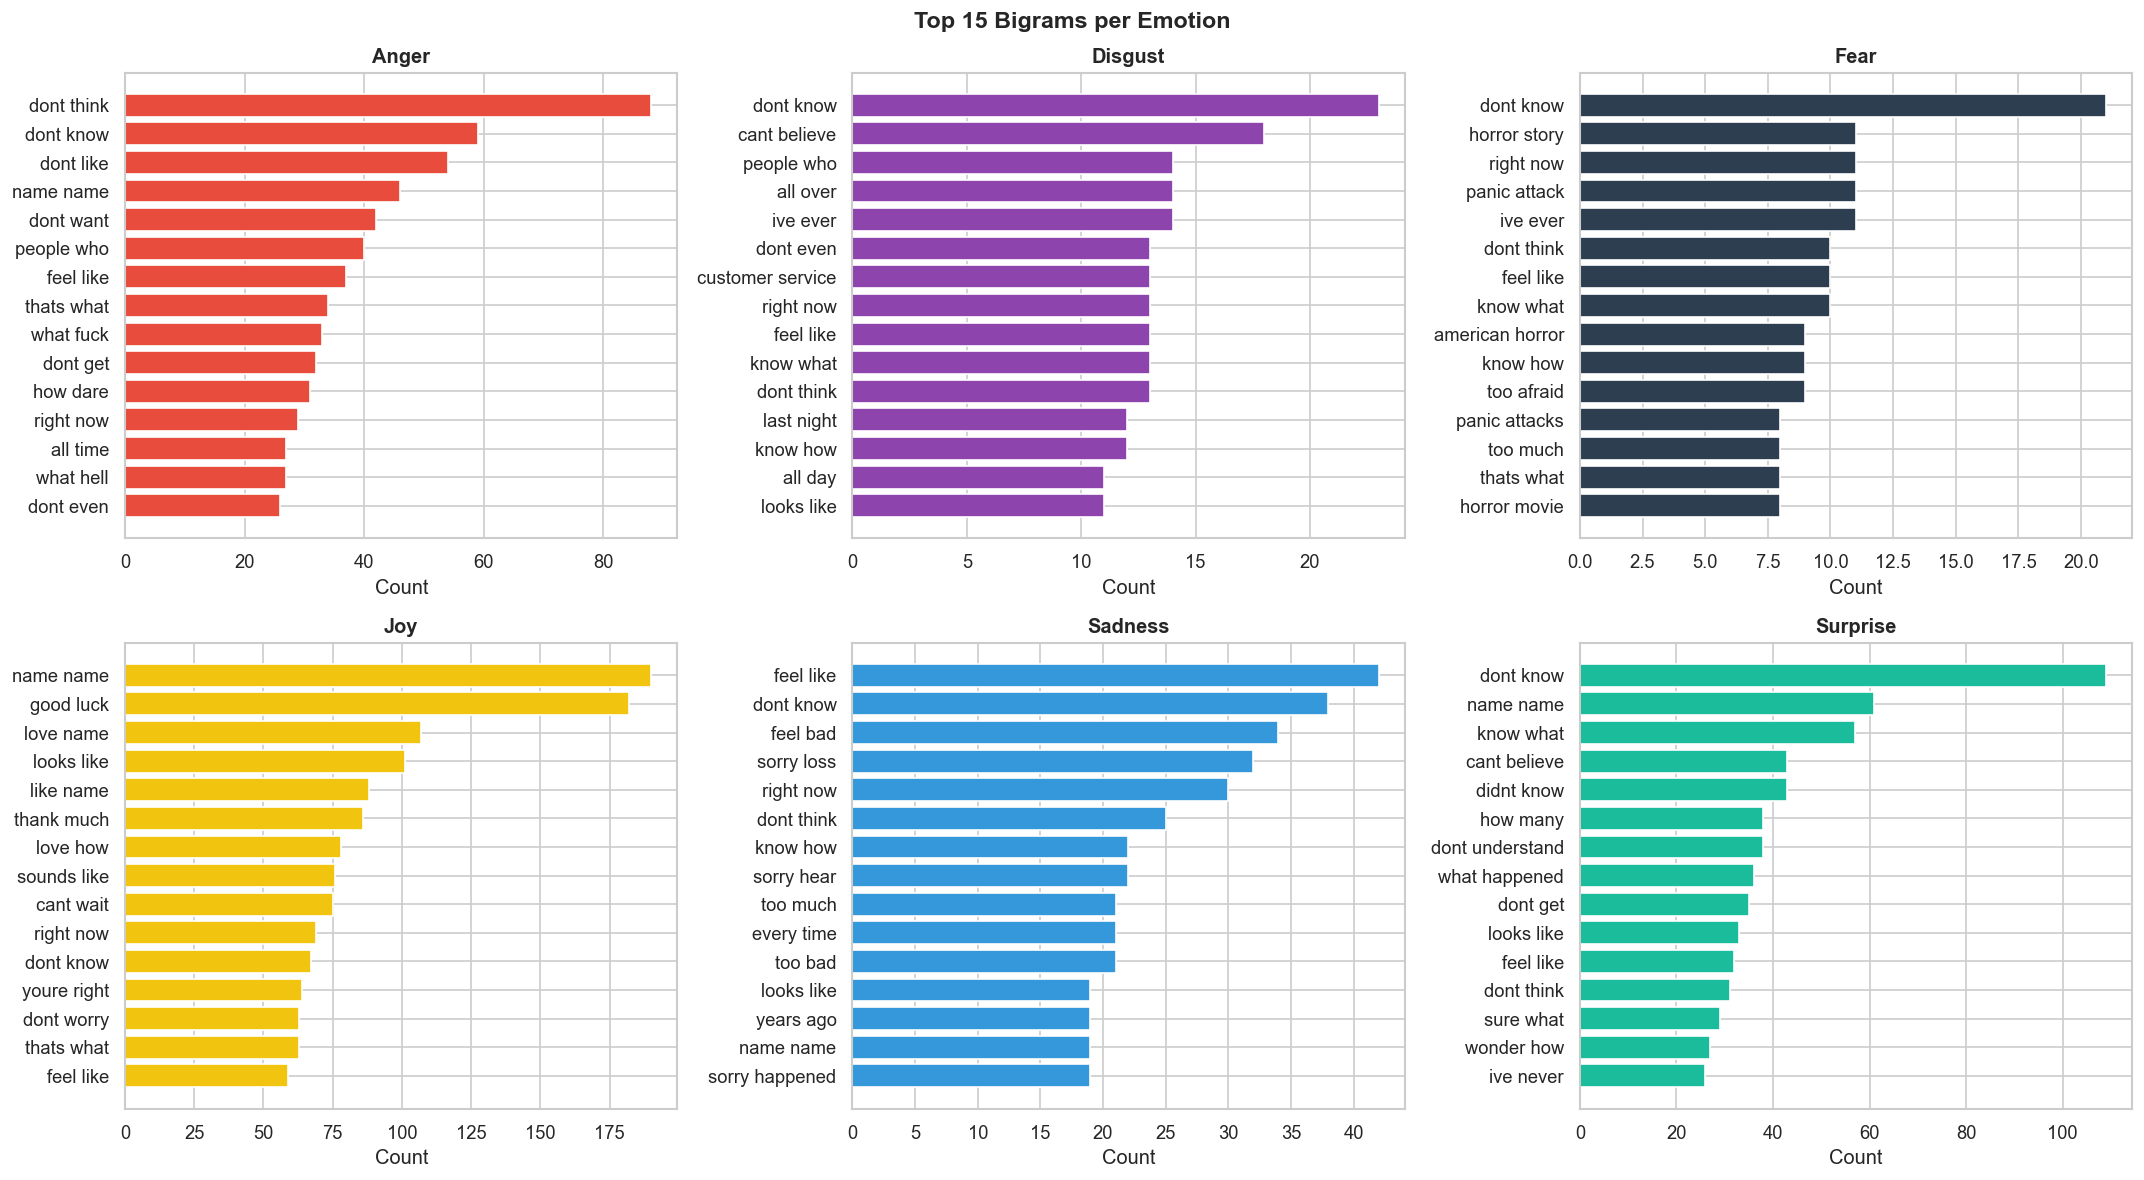

In [11]:
# Top bigrams
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 15 Bigrams per Emotion', fontsize=14, fontweight='bold')

for ax, emo in zip(axes.flatten(), EMOTION_COLS):
    texts = df[df[emo] == 1]['text']
    top = get_top_ngrams(texts, n=2, top_k=15)
    if not top: continue
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=EMOTION_COLORS[emo], edgecolor='white')
    ax.set_title(f'{emo.capitalize()}', fontweight='bold')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

---
## 9. Vocabulary Overlap Between Emotions

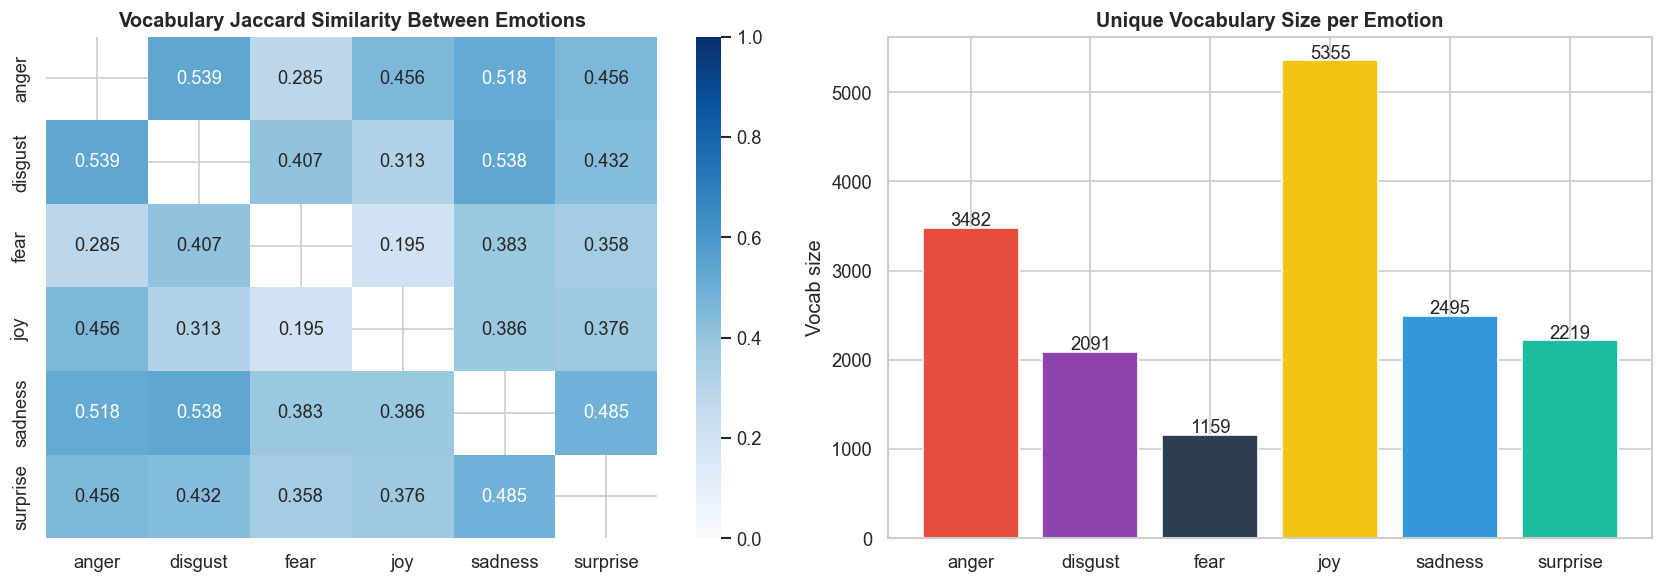


=== Top 10 Exclusive Words per Emotion (not in others) ===
  anger     : ['generic', 'democrats', 'tryna', 'annoys', 'greedy', 'unacceptable', 'cunts', 'utter', 'discrimination', 'socially']
  disgust   : ['disgust', 'establishment', 'nicoles', 'nytimes', 'elway', 'smelly', 'hollywood', 'thehill', 'preaching', 'epicentre']
  fear      : ['scariest', 'frightening', 'alert', 'cray', 'danish', 'onus', 'gathering', 'libeling', 'campus', 'politicususa']
  joy       : ['enjoyed', 'bless', 'excellent', 'cheerful', 'gorgeous', 'delicious', 'grateful', 'promise', 'gift', 'healthy']
  sadness   : ['embarrassment', 'upsetting', 'disheartened', 'remembering', 'laptop', 'disheartening', 'sadden', 'trap', 'severe', 'inconsolable']
  surprise  : ['confusing', 'surprisingly', 'pleasantly', 'ohhhhh', 'volume', 'mustve', 'offering', 'shockingly', 'consent', 'attempts']


In [12]:
def get_vocab(texts, min_count=3):
    cnt = Counter()
    for text in texts:
        tokens = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()).split()
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
        cnt.update(tokens)
    return set(w for w, c in cnt.items() if c >= min_count)

emo_vocabs = {emo: get_vocab(df[df[emo] == 1]['text']) for emo in EMOTION_COLS}

# Jaccard overlap matrix
overlap_matrix = pd.DataFrame(index=EMOTION_COLS, columns=EMOTION_COLS, dtype=float)
for e1 in EMOTION_COLS:
    for e2 in EMOTION_COLS:
        inter = len(emo_vocabs[e1] & emo_vocabs[e2])
        union = len(emo_vocabs[e1] | emo_vocabs[e2])
        overlap_matrix.loc[e1, e2] = inter / union if union > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask = np.eye(len(EMOTION_COLS), dtype=bool)
sns.heatmap(overlap_matrix.astype(float), mask=mask, annot=True, fmt='.3f',
            cmap='Blues', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Vocabulary Jaccard Similarity Between Emotions', fontweight='bold')

# Vocab sizes
sizes = {emo: len(v) for emo, v in emo_vocabs.items()}
colors = [EMOTION_COLORS[e] for e in sizes.keys()]
axes[1].bar(sizes.keys(), sizes.values(), color=colors, edgecolor='white')
axes[1].set_title('Unique Vocabulary Size per Emotion', fontweight='bold')
axes[1].set_ylabel('Vocab size')
for i, (k, v) in enumerate(sizes.items()):
    axes[1].text(i, v + 20, str(v), ha='center')

plt.tight_layout()
plt.show()

# Exclusive words per emotion
print('\n=== Top 10 Exclusive Words per Emotion (not in others) ===')
for emo in EMOTION_COLS:
    others = set().union(*[emo_vocabs[e] for e in EMOTION_COLS if e != emo])
    exclusive = emo_vocabs[emo] - others
    # rank by freq
    cnt = Counter()
    for text in df[df[emo] == 1]['text']:
        tokens = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()).split()
        cnt.update([t for t in tokens if t in exclusive])
    top_excl = [w for w, _ in cnt.most_common(10)]
    print(f'  {emo:10}: {top_excl}')

---
## 10. Text Noise & Quality Analysis

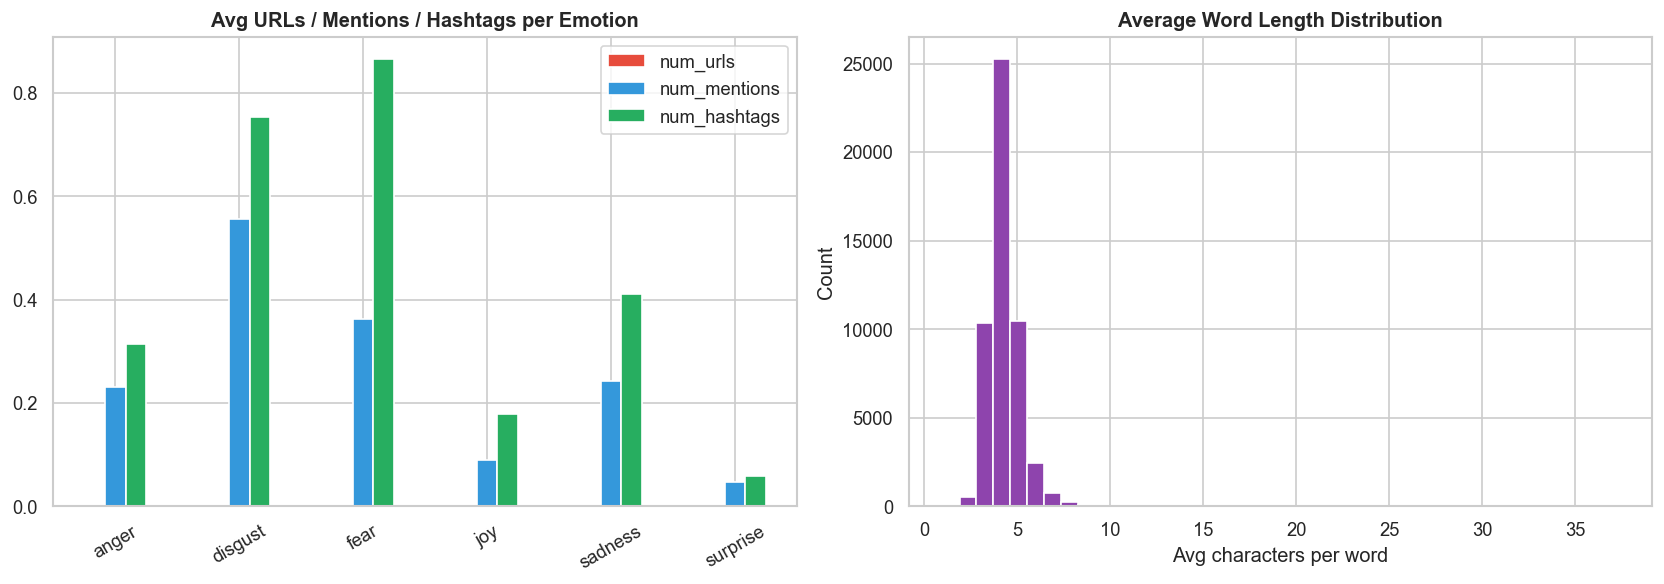


=== Noise Feature Statistics ===


,num_urls,num_mentions,num_hashtags,num_numbers,num_punct,avg_word_len
count,50248.0,50248.000,50248.000,50248.000,50248.000,50245.000
mean,0.0,0.086,0.145,0.109,3.225,4.327
std,0.0,0.392,0.742,0.644,3.425,0.893
min,0.0,0.000,0.000,0.000,0.000,1.000
25%,0.0,0.000,0.000,0.000,1.000,3.786
50%,0.0,0.000,0.000,0.000,3.000,4.200
75%,0.0,0.000,0.000,0.000,4.000,4.714
max,0.0,9.000,16.000,107.000,475.000,37.333


In [13]:
df['num_urls']      = df['text'].str.count(r'http\S+|www\.\S+')
df['num_mentions']  = df['text'].str.count(r'@\w+')
df['num_hashtags']  = df['text'].str.count(r'#\w+')
df['num_numbers']   = df['text'].str.count(r'\b\d+\b')
df['num_punct']     = df['text'].str.count(r'[^\w\s]')
df['avg_word_len']  = df['text'].apply(
    lambda x: np.mean([len(w) for w in re.sub(r'[^a-zA-Z\s]', '', str(x)).split()]) if str(x).strip() else 0
)

noise_cols = ['num_urls','num_mentions','num_hashtags','num_numbers','num_punct']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average noise per emotion
noise_emo = []
for emo in EMOTION_COLS:
    sub = df[df[emo] == 1]
    row = {'emotion': emo}
    for c in noise_cols: row[c] = sub[c].mean()
    noise_emo.append(row)
noise_df = pd.DataFrame(noise_emo).set_index('emotion')

noise_df[['num_urls','num_mentions','num_hashtags']].plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#3498db','#27ae60'], edgecolor='white')
axes[0].set_title('Avg URLs / Mentions / Hashtags per Emotion', fontweight='bold')
axes[0].set_xlabel(''); axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# Average word length distribution
axes[1].hist(df['avg_word_len'], bins=40, color='#8e44ad', edgecolor='white')
axes[1].set_title('Average Word Length Distribution', fontweight='bold')
axes[1].set_xlabel('Avg characters per word')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('\n=== Noise Feature Statistics ===')
display(df[noise_cols + ['avg_word_len']].describe().round(3))

---
## 11. Type-Token Ratio (TTR) — Lexical Diversity

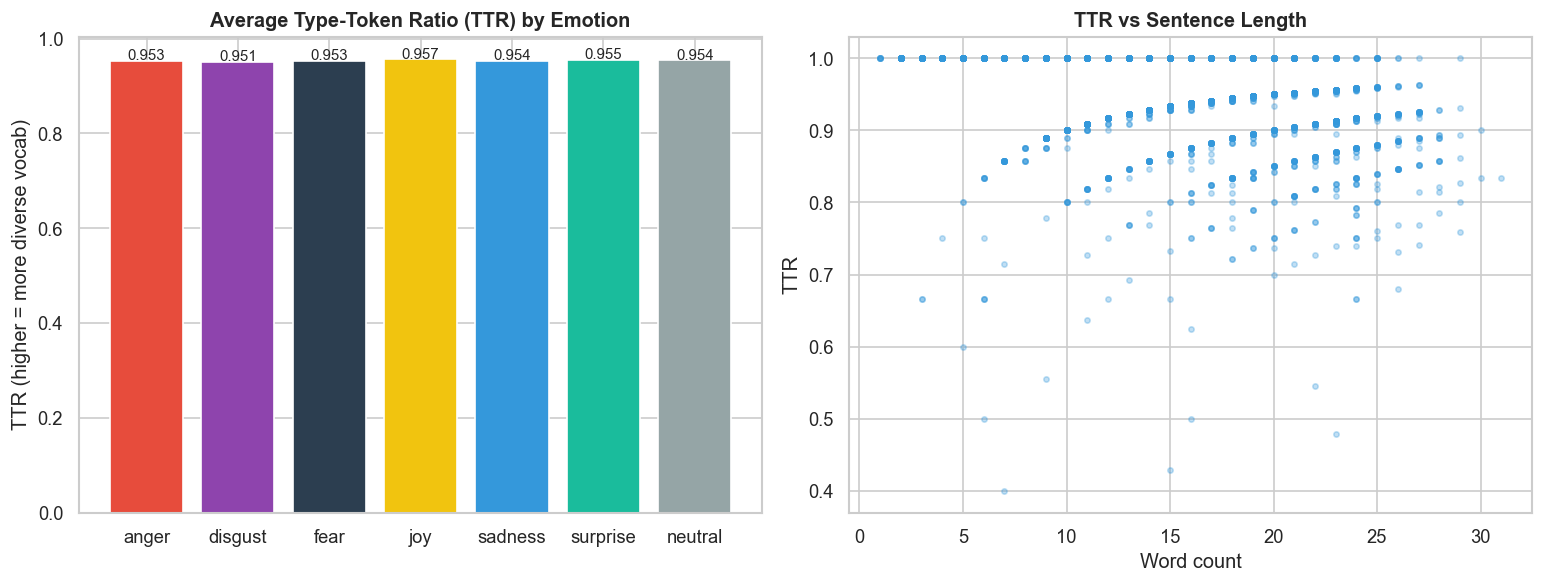

In [14]:
def ttr(text):
    tokens = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()).split()
    if len(tokens) == 0: return 0
    return len(set(tokens)) / len(tokens)

df['ttr'] = df['text'].apply(ttr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# TTR by emotion
ttr_emo = {}
for emo in EMOTION_COLS:
    ttr_emo[emo] = df[df[emo] == 1]['ttr'].values
ttr_emo['neutral'] = df[df['num_emotions'] == 0]['ttr'].values

ttr_means = {k: np.mean(v) for k, v in ttr_emo.items()}
colors = [EMOTION_COLORS[e] for e in ttr_means.keys()]
axes[0].bar(ttr_means.keys(), ttr_means.values(), color=colors, edgecolor='white')
axes[0].set_title('Average Type-Token Ratio (TTR) by Emotion', fontweight='bold')
axes[0].set_ylabel('TTR (higher = more diverse vocab)')
for i, (k, v) in enumerate(ttr_means.items()):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

# TTR vs word length scatter
sample = df.sample(min(3000, len(df)), random_state=42)
axes[1].scatter(sample['word_len'], sample['ttr'],
                alpha=0.3, s=10, color='#3498db')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('TTR')
axes[1].set_title('TTR vs Sentence Length', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 12. Summary Statistics Table

In [15]:
summary_rows = []
for emo in EMOTION_COLS + ['neutral']:
    if emo == 'neutral':
        sub = df[df['num_emotions'] == 0]
    else:
        sub = df[df[emo] == 1]
    summary_rows.append({
        'emotion':       emo,
        'count':         len(sub),
        'pct_%':         round(len(sub)/len(df)*100, 2),
        'avg_words':     round(sub['word_len'].mean(), 1),
        'median_words':  round(sub['word_len'].median(), 1),
        'avg_chars':     round(sub['char_len'].mean(), 1),
        'avg_ttr':       round(sub['ttr'].mean(), 3),
        'pct_mention_%': round(sub['has_mention'].mean()*100, 1),
        'pct_hashtag_%': round(sub['has_hashtag'].mean()*100, 1),
        'pct_url_%':     round(sub['has_url'].mean()*100, 1),
        'pct_emoji_%':   round(sub['has_emoji'].mean()*100, 1),
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Full Summary Table ===')
display(
    summary_df.style
    .background_gradient(subset=['count'], cmap='Blues')
    .background_gradient(subset=['avg_words'], cmap='Greens')
    .background_gradient(subset=['avg_ttr'], cmap='Purples')
    .format({'pct_%': '{:.2f}%', 'pct_mention_%': '{:.1f}%',
             'pct_hashtag_%': '{:.1f}%', 'pct_url_%': '{:.1f}%',
             'pct_emoji_%': '{:.1f}%'})
)

=== Full Summary Table ===


,emotion,count,pct_%,avg_words,median_words,avg_chars,avg_ttr,pct_mention_%,pct_hashtag_%,pct_url_%,pct_emoji_%
0,anger,7813,15.55%,14.500000,15.000000,81.400000,0.953000,16.2%,14.1%,0.0%,4.1%
1,disgust,3366,6.70%,15.900000,16.000000,92.600000,0.951000,38.7%,33.8%,0.0%,7.8%
2,fear,1941,3.86%,15.200000,16.000000,88.000000,0.953000,24.6%,34.7%,0.0%,7.2%
3,joy,19794,39.39%,13.200000,13.000000,71.300000,0.957000,6.5%,6.8%,0.0%,3.9%
4,sadness,5392,10.73%,15.000000,15.000000,82.700000,0.954000,17.3%,18.8%,0.0%,6.5%
5,surprise,5418,10.78%,14.000000,14.000000,75.000000,0.955000,3.2%,3.1%,0.0%,2.7%
6,neutral,14497,28.85%,12.500000,12.000000,67.500000,0.954000,1.0%,0.9%,0.0%,0.6%
